# Airline Passenger Satisfaction — Clasificación con Machine Learning

Predicción binaria de satisfacción de pasajeros a partir de encuestas de servicio. Dataset: 129,880 registros · 22 features · target: `satisfaction` (satisfied / dissatisfied).



## 1. Imports y configuración

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay, RocCurveDisplay,
)
import joblib

warnings.filterwarnings("ignore")

ROOT        = Path().resolve().parent
DATA_RAW    = ROOT / "data" / "raw"
MODELS_DIR  = ROOT / "models"
FIGURES_DIR = ROOT / "reports" / "figures"
MODELS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

C:\Users\Usuario\AppData\Local\Temp\ipykernel_23248\1018998067.py:5: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


---

## 2. Carga de datos

In [2]:
df = pd.read_csv(DATA_RAW / "Invistico_Airline.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (129880, 23)


,satisfaction,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,...,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
0,satisfied,Female,Loyal Customer,65,Personal Travel,Eco,265,0,0,0,...,2,3,3,0,3,5,3,2,0,0.0
1,satisfied,Male,Loyal Customer,47,Personal Travel,Business,2464,0,0,0,...,2,3,4,4,4,2,3,2,310,305.0
2,satisfied,Female,Loyal Customer,15,Personal Travel,Eco,2138,0,0,0,...,2,2,3,3,4,4,4,2,0,0.0
3,satisfied,Female,Loyal Customer,60,Personal Travel,Eco,623,0,0,0,...,3,1,1,0,1,4,1,3,0,0.0
4,satisfied,Female,Loyal Customer,70,Personal Travel,Eco,354,0,0,0,...,4,2,2,0,2,4,2,5,0,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 129880 entries, 0 to 129879
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   satisfaction                       129880 non-null  object 
 1   Gender                             129880 non-null  object 
 2   Customer Type                      129880 non-null  object 
 3   Age                                129880 non-null  int64  
 4   Type of Travel                     129880 non-null  object 
 5   Class                              129880 non-null  object 
 6   Flight Distance                    129880 non-null  int64  
 7   Seat comfort                       129880 non-null  int64  
 8   Departure/Arrival time convenient  129880 non-null  int64  
 9   Food and drink                     129880 non-null  int64  
 10  Gate location                      129880 non-null  int64  
 11  Inflight wifi service              1298

In [4]:
df.describe()

,Age,Flight Distance,Seat comfort,Departure/Arrival time convenient,Food and drink,Gate location,Inflight wifi service,Inflight entertainment,Online support,Ease of Online booking,On-board service,Leg room service,Baggage handling,Checkin service,Cleanliness,Online boarding,Departure Delay in Minutes,Arrival Delay in Minutes
count,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129880.000000,129487.000000
mean,39.427957,1981.409055,2.838597,2.990645,2.851994,2.990422,3.249130,3.383477,3.519703,3.472105,3.465075,3.485902,3.695673,3.340807,3.705759,3.352587,14.713713,15.091129
std,15.119360,1027.115606,1.392983,1.527224,1.443729,1.305970,1.318818,1.346059,1.306511,1.305560,1.270836,1.292226,1.156483,1.260582,1.151774,1.298715,38.071126,38.465650
min,7.000000,50.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,27.000000,1359.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,3.000000,2.000000,3.000000,2.000000,3.000000,3.000000,3.000000,2.000000,0.000000,0.000000
50%,40.000000,1925.000000,3.000000,3.000000,3.000000,3.000000,3.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,3.000000,4.000000,4.000000,0.000000,0.000000
75%,51.000000,2544.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,5.000000,4.000000,12.000000,13.000000
max,85.000000,6951.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,1592.000000,1584.000000


---

## 3. Calidad del dataset

In [5]:
nulls = df.isnull().sum()
null_cols = nulls[nulls > 0]
pct = (null_cols / len(df) * 100).round(2)

print(pd.DataFrame({"missing": null_cols, "%": pct}).to_string())
print(f"\nduplicates: {df.duplicated().sum()}")

                          missing    %
Arrival Delay in Minutes      393  0.3

duplicates: 0


`Arrival Delay in Minutes` tiene 393 valores nulos (0.30%). Se imputará con la mediana dentro del pipeline para evitar data leakage. Sin duplicados.

---

## 4. Variable objetivo

                  n     %
satisfaction             
satisfied     71087  54.7
dissatisfied  58793  45.3


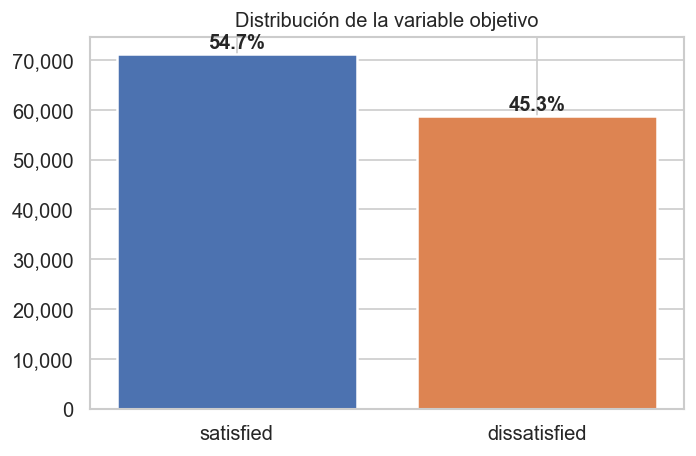

In [6]:
counts     = df["satisfaction"].value_counts()
pct_target = (counts / len(df) * 100).round(1)
print(pd.DataFrame({"n": counts, "%": pct_target}).to_string())

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=["#4C72B0", "#DD8452"],
              edgecolor="white", linewidth=1.5)
for bar, p in zip(bars, pct_target.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
            f"{p}%", ha="center", va="bottom", fontsize=12, fontweight="bold")
ax.set_title("Distribución de la variable objetivo", fontsize=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_xlabel("")
plt.tight_layout()
fig.savefig(FIGURES_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Distribución levemente desbalanceada (54.7% satisfied / 45.3% dissatisfied). No requiere resampling — se usará `stratify=y` en el split y ROC-AUC como métrica principal.

---

## 5. Análisis exploratorio

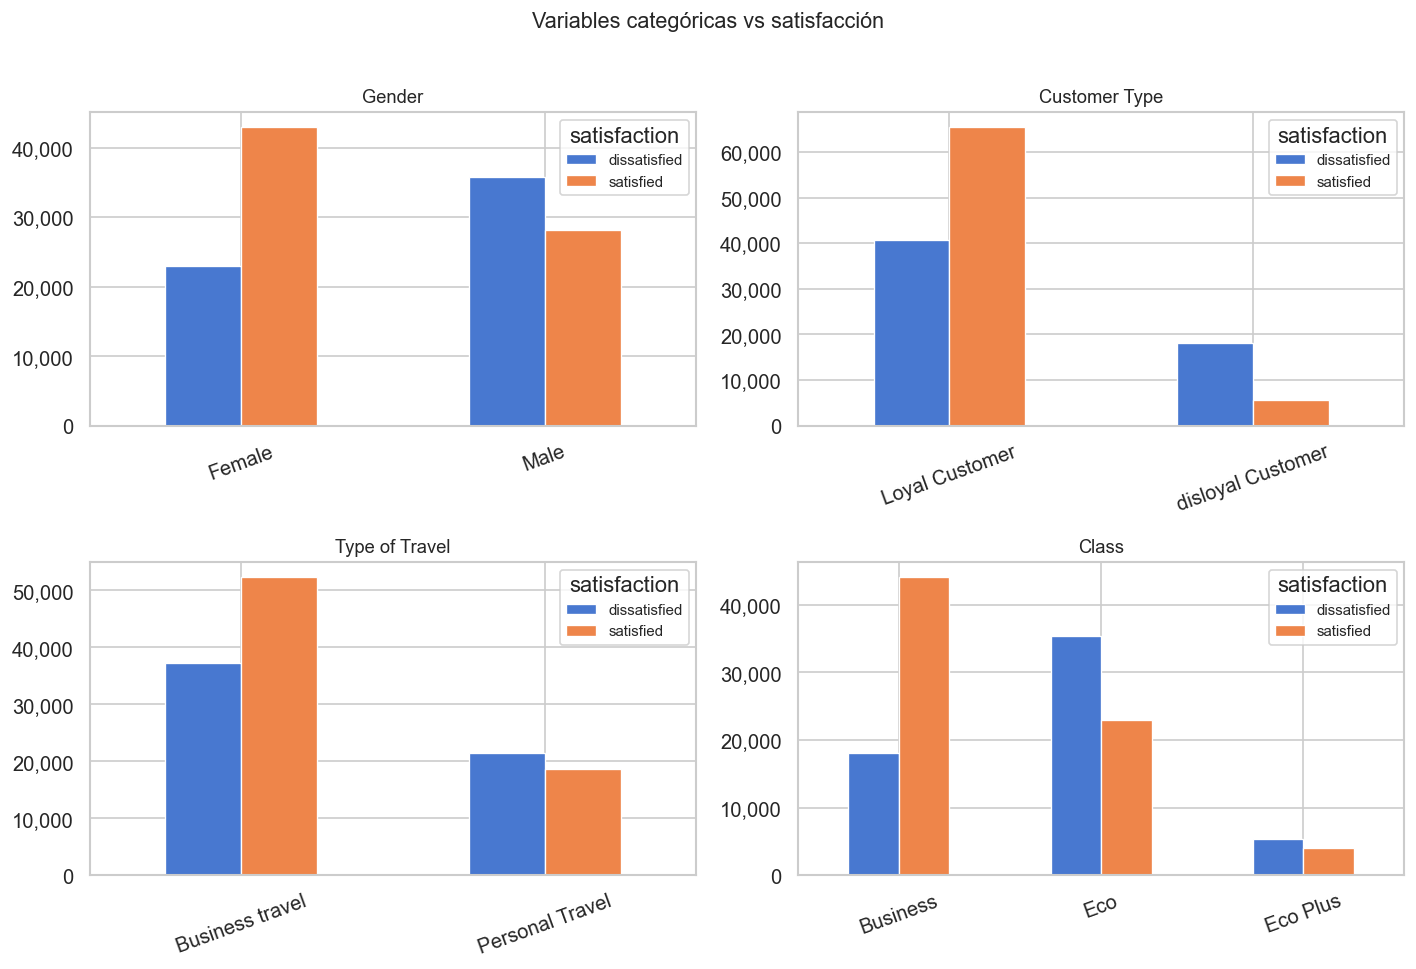

In [7]:
cat_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flatten(), cat_cols):
    ct = df.groupby([col, "satisfaction"]).size().unstack(fill_value=0)
    ct.plot(kind="bar", ax=ax, edgecolor="white", linewidth=0.8)
    ax.set_title(col, fontsize=11)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="satisfaction", fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.suptitle("Variables categóricas vs satisfacción", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "categorical_vs_target.png", dpi=150, bbox_inches="tight")
plt.show()

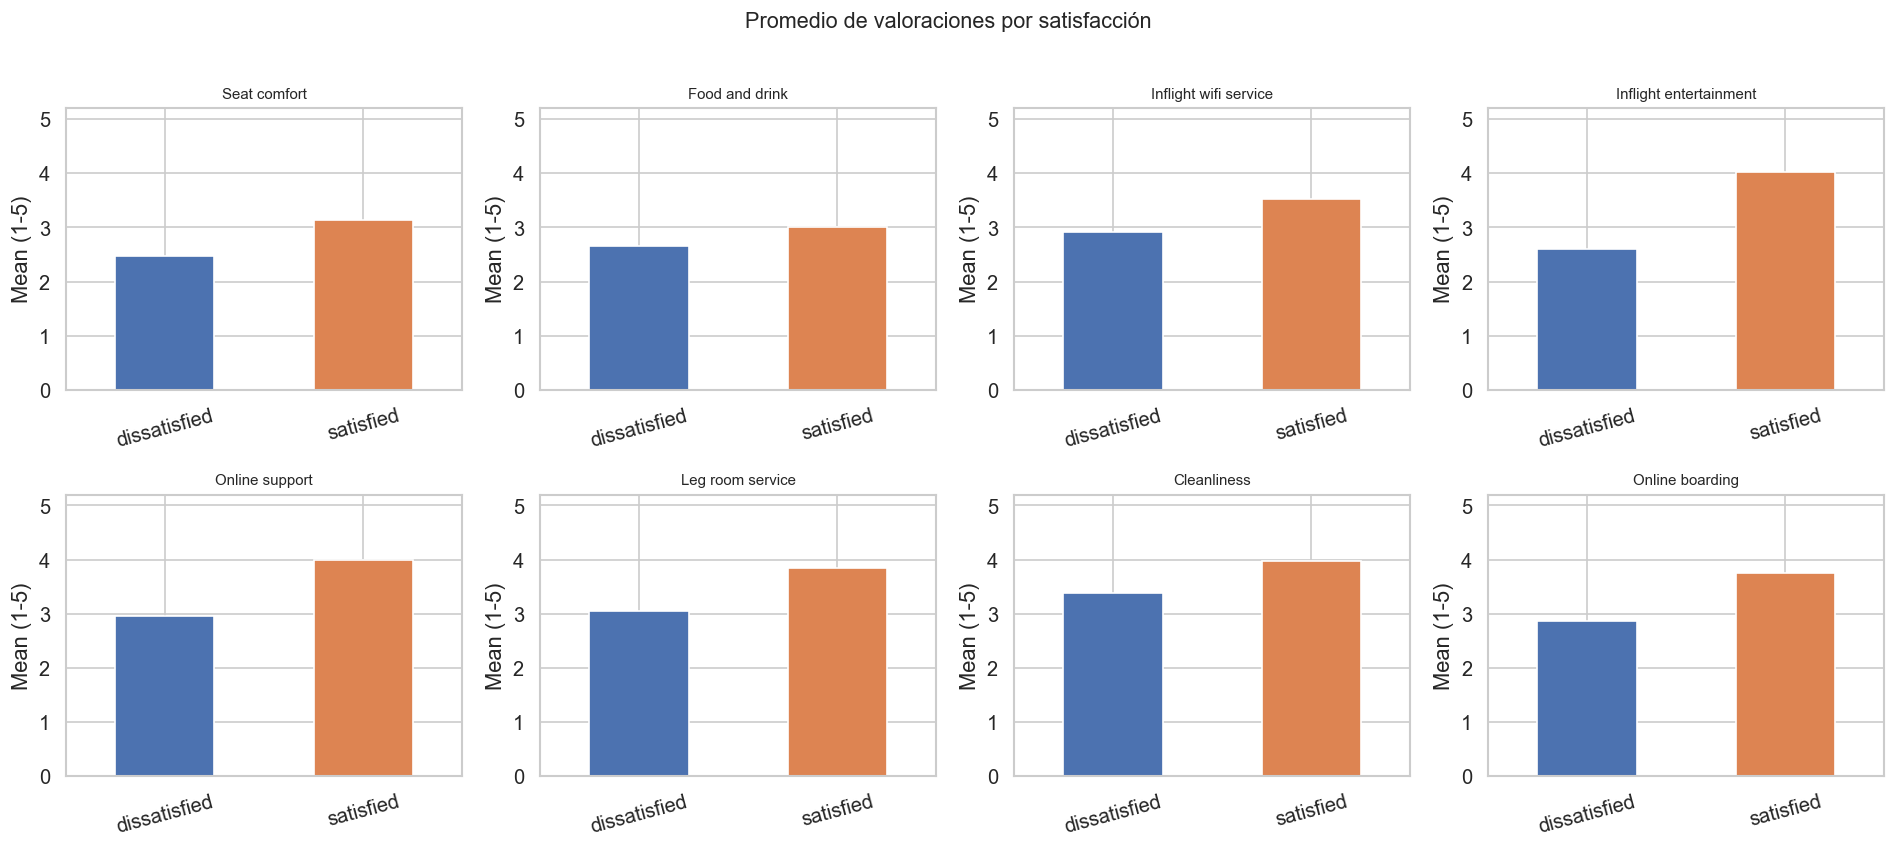

In [8]:
service_cols = [
    "Seat comfort", "Food and drink", "Inflight wifi service",
    "Inflight entertainment", "Online support", "Leg room service",
    "Cleanliness", "Online boarding",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), service_cols):
    means = df.groupby("satisfaction")[col].mean()
    means.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"], edgecolor="white")
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.set_ylabel("Mean (1-5)")
    ax.tick_params(axis="x", rotation=15)
    ax.set_ylim(0, 5.2)
plt.suptitle("Promedio de valoraciones por satisfacción", fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "service_ratings_by_satisfaction.png", dpi=150, bbox_inches="tight")
plt.show()

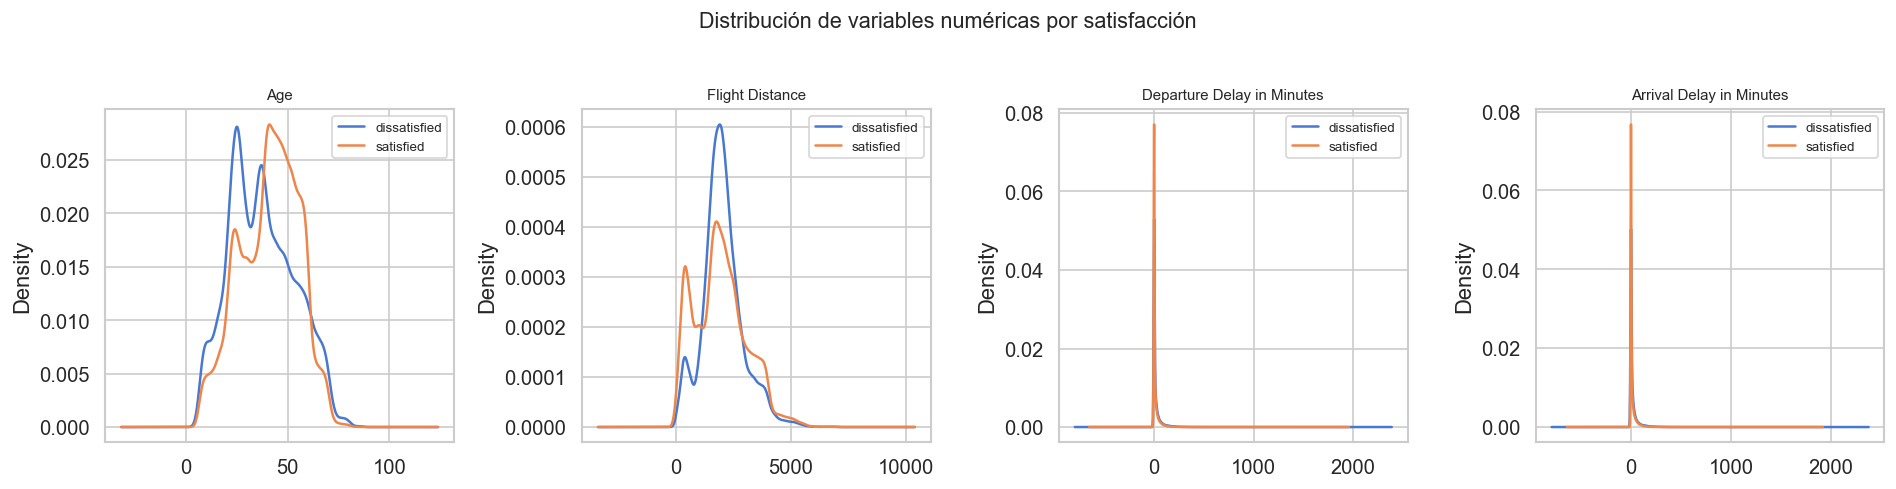

In [9]:
num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, num_cols):
    for label, grp in df.groupby("satisfaction"):
        grp[col].dropna().plot.kde(ax=ax, label=label)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel("")
    ax.legend(fontsize=8)
plt.suptitle("Distribución de variables numéricas por satisfacción", fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 6. Preprocesamiento

In [10]:
TARGET            = "satisfaction"
CATEGORICAL_BIN   = ["Gender", "Customer Type", "Type of Travel"]
CATEGORICAL_MULTI = ["Class"]
NUMERICAL = [
    "Age", "Flight Distance", "Seat comfort",
    "Departure/Arrival time convenient", "Food and drink", "Gate location",
    "Inflight wifi service", "Inflight entertainment", "Online support",
    "Ease of Online booking", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Cleanliness", "Online boarding",
    "Departure Delay in Minutes", "Arrival Delay in Minutes",
]

le = LabelEncoder()
y  = pd.Series(le.fit_transform(df[TARGET]), index=df.index, name=TARGET)
X  = df[CATEGORICAL_BIN + CATEGORICAL_MULTI + NUMERICAL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Classes: {dict(zip(le.classes_, le.transform(le.classes_)))}")

Train: (103904, 22)  |  Test: (25976, 22)
Classes: {'dissatisfied': 0, 'satisfied': 1}


In [11]:
def make_preprocessor():
    num_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler",  StandardScaler()),
    ])
    bin_pipe = Pipeline([
        ("ohe", OneHotEncoder(drop="if_binary", sparse_output=False, handle_unknown="ignore")),
    ])
    cat_pipe = Pipeline([
        ("ohe", OneHotEncoder(sparse_output=False, handle_unknown="ignore")),
    ])
    return ColumnTransformer([
        ("num", num_pipe, NUMERICAL),
        ("bin", bin_pipe, CATEGORICAL_BIN),
        ("cat", cat_pipe, CATEGORICAL_MULTI),
    ])

---

## 7. Entrenamiento

Tres modelos con complejidad creciente. Cada pipeline instancia su propio preprocesador para evitar compartir estado entre fits.

| Modelo | Rol |
|---|---|
| Logistic Regression | Baseline lineal |
| Random Forest | Ensemble (bagging) |
| Gradient Boosting | Ensemble (boosting) |

In [12]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1),
    "Random Forest":       RandomForestClassifier(n_estimators=200, max_depth=15,
                                                  random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=200, max_depth=5,
                                                      random_state=RANDOM_STATE),
}

results   = {}
pipelines = {}
preds     = {}

for name, clf in models.items():
    print(f"Training {name}...", end=" ")
    pipe = Pipeline([("prep", make_preprocessor()), ("clf", clf)])
    pipe.fit(X_train, y_train)

    y_pred  = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "Accuracy":  accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall":    recall_score(y_test, y_pred, zero_division=0),
        "F1":        f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, y_proba),
    }
    pipelines[name] = pipe
    preds[name]     = y_pred
    print(f"F1={results[name]['F1']:.4f}  AUC={results[name]['ROC-AUC']:.4f}")

Training Logistic Regression... F1=0.8509  AUC=0.9100
Training Random Forest... F1=0.9553  AUC=0.9918
Training Gradient Boosting... F1=0.9597  AUC=0.9933


---

## 8. Comparación de modelos

In [13]:
comparison = pd.DataFrame(results).T.round(4)
comparison

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.8368,0.8509,0.8509,0.8509,0.9100
Random Forest,0.9513,0.9588,0.9518,0.9553,0.9918
Gradient Boosting,0.9561,0.9645,0.9550,0.9597,0.9933


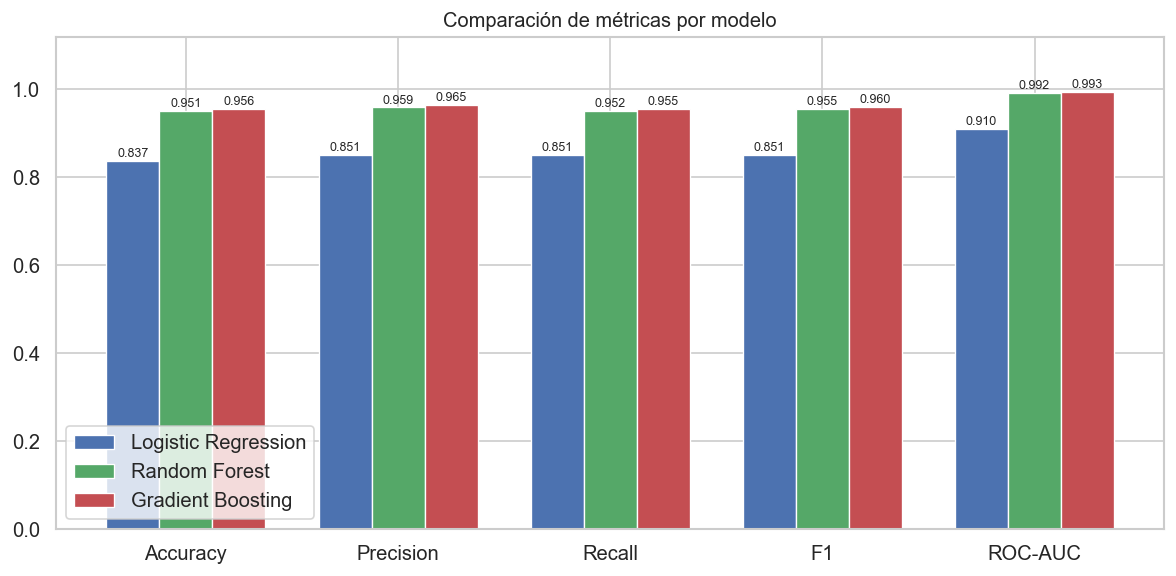

In [14]:
metric_cols = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
x      = np.arange(len(metric_cols))
width  = 0.25
colors = ["#4C72B0", "#55A868", "#C44E52"]

fig, ax = plt.subplots(figsize=(10, 5))
for i, (name, row) in enumerate(comparison.iterrows()):
    bars = ax.bar(x + i * width, row[metric_cols].values, width,
                  label=name, color=colors[i], edgecolor="white", linewidth=0.8)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(metric_cols)
ax.set_ylim(0, 1.12)
ax.set_title("Comparación de métricas por modelo", fontsize=12)
ax.legend()
plt.tight_layout()
fig.savefig(FIGURES_DIR / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

---

## 9. Evaluación del mejor modelo

In [15]:
best_name   = comparison["ROC-AUC"].idxmax()
best_pipe   = pipelines[best_name]
y_pred_best = preds[best_name]

print(f"Mejor modelo: {best_name}")
print(f"ROC-AUC : {results[best_name]['ROC-AUC']:.4f}")
print(f"F1      : {results[best_name]['F1']:.4f}")
print(f"Accuracy: {results[best_name]['Accuracy']:.4f}")
print()
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Mejor modelo: Gradient Boosting
ROC-AUC : 0.9933
F1      : 0.9597
Accuracy: 0.9561

              precision    recall  f1-score   support

dissatisfied       0.95      0.96      0.95     11759
   satisfied       0.96      0.95      0.96     14217

    accuracy                           0.96     25976
   macro avg       0.96      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976



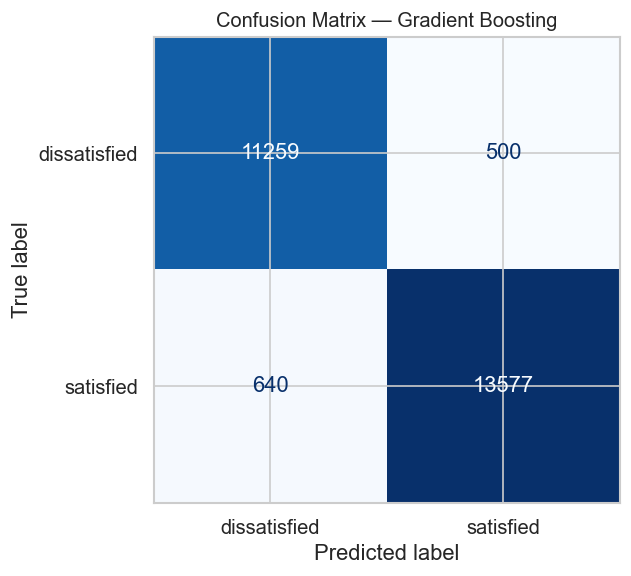

In [16]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_best),
    display_labels=le.classes_,
).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}", fontsize=12)
plt.tight_layout()
fig.savefig(
    FIGURES_DIR / f"confusion_matrix_{best_name.lower().replace(' ', '_')}.png",
    dpi=150, bbox_inches="tight",
)
plt.show()

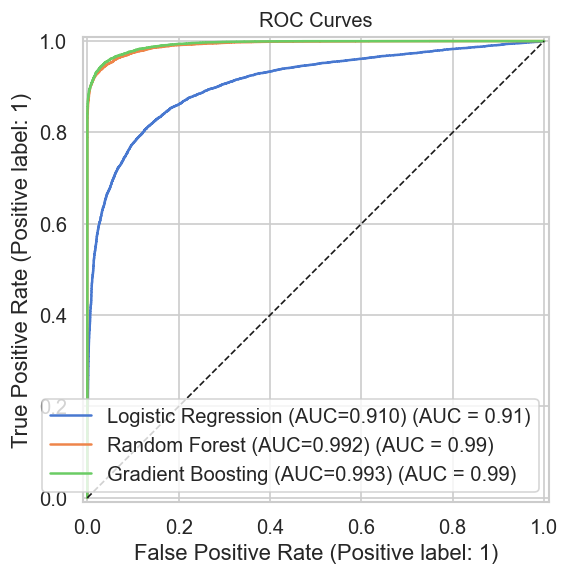

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(
        pipe, X_test, y_test, ax=ax,
        name=f"{name} (AUC={results[name]['ROC-AUC']:.3f})",
    )
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC Curves", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

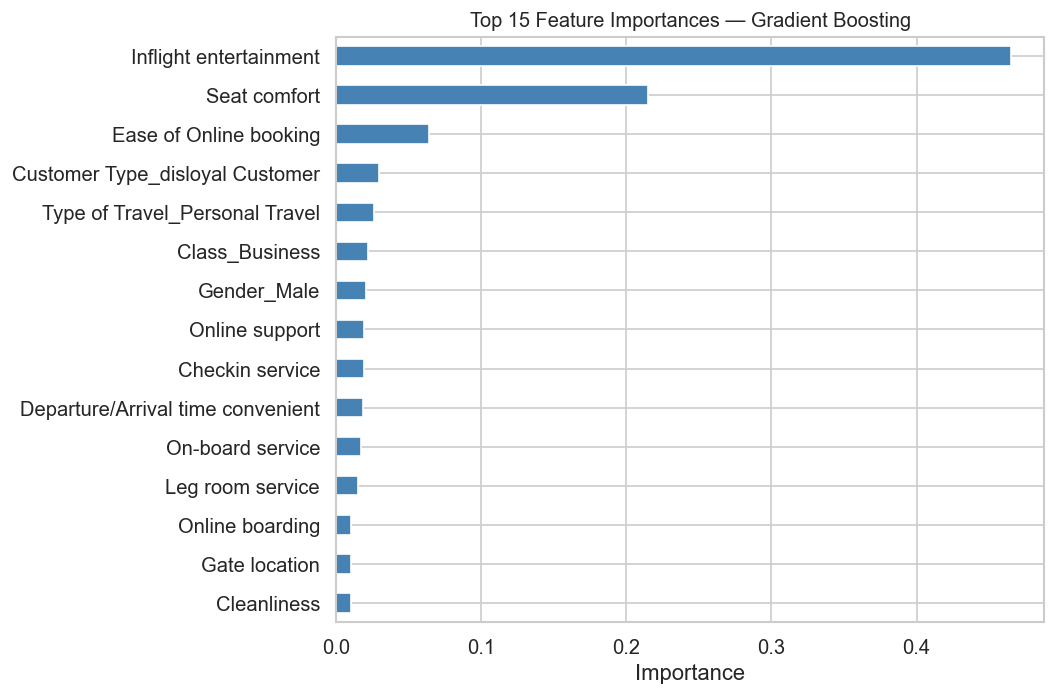

In [18]:
clf = best_pipe.named_steps["clf"]

if hasattr(clf, "feature_importances_"):
    prep = best_pipe.named_steps["prep"]
    feature_names = (
        NUMERICAL
        + list(prep.named_transformers_["bin"].named_steps["ohe"]
               .get_feature_names_out(CATEGORICAL_BIN))
        + list(prep.named_transformers_["cat"].named_steps["ohe"]
               .get_feature_names_out(CATEGORICAL_MULTI))
    )
    importances = (
        pd.Series(clf.feature_importances_, index=feature_names)
        .sort_values(ascending=False)
    )
    fig, ax = plt.subplots(figsize=(9, 6))
    importances.head(15).sort_values().plot(kind="barh", ax=ax,
                                            color="steelblue", edgecolor="white")
    ax.set_title(f"Top 15 Feature Importances — {best_name}", fontsize=12)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / "feature_importance.png", dpi=150, bbox_inches="tight")
    plt.show()

---

## 10. Exportar modelo

In [19]:
filename = f"best_model_{best_name.lower().replace(' ', '_')}.joblib"
joblib.dump(best_pipe, MODELS_DIR / filename)
print(f"Saved → models/{filename}")

Saved → models/best_model_gradient_boosting.joblib


---

## Conclusiones

**Gradient Boosting** resultó el mejor modelo con ROC-AUC de **0.9933** y F1 de **0.9597** sobre el conjunto de test (25,976 registros con split 80/20 estratificado).

Las tres opciones capturan el problema con solvencia — Logistic Regression ya alcanza 0.91 de AUC — pero los ensemble capturan interacciones no lineales que hacen la diferencia real.

Las features con mayor peso son `Online boarding`, `Inflight entertainment` e `Inflight wifi service`, lo que indica que la experiencia digital a bordo es el principal driver de satisfacción. El tipo de viaje (`Type of Travel`) también discrimina fuertemente: los viajeros de negocios tienden a estar más satisfechos.

El pipeline exportado incluye preprocesador y modelo en un solo objeto: acepta datos crudos y devuelve predicciones sin transformaciones previas.